## 문제 인식

오퍼를 확인하지 않은 고객에게도 리워드가 자동 지급된다.  
→ 구매는 오퍼 없이도 발생 — 기존 매출에 비용이 추가되는 구조

**전체 완료의 16.5%가 이 구조에 해당** (C유형: View 없이 Complete)

---

| 구조 | 의미 |
|------|------|
| 오퍼 확인 → 구매 (A유형) | 오퍼가 구매를 유도함 — 마케팅 효과 있음 |
| 오퍼 미확인 → 구매 (C유형) | 구매는 발생하지만 오퍼 기여 없음 — 비용 낭비 |

→ 오퍼 구조 재설계 필요: 자동 지급 → Opt-in 전환

---

# 05. 실행 전략 — Opt-in 전환 및 세그먼트별 오퍼 운영

**분석 결과 → 행동:**

| 분석 결과 | 실행 방향 |
|-----------|----------|
| 16.5% 우연완료 = 리워드 낭비 | Opt-in 전환 → C유형 자동 제거 |
| 루틴형 고객 30% = 오퍼 불필요 | 오퍼 50% 축소 + 절감액 재배분 |
| 고소득 ROI 음수 구조 | 해당 세그먼트 오퍼 타입 전환 |

**예상 효과:**

| 항목 | 수치 |
|------|------|
| Opt-in 전환 시 최대 절감 | **$260,000** (전체 규모 확장 기준) |
| 루틴형 오퍼 50% 축소 | 매출 손실 < 비용 절감 |
| 글로벌 확장 시 추가 절감 | 수십만 달러 이상 |

---

## 0. 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rc("font", family="Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False

In [2]:
# 마스터 테이블 및 분석 데이터 로드
mt = pd.read_csv("../data/processed/prep_master_table.csv")
df = pd.read_csv("../data/processed/starbucks_EDA_data.csv")

In [3]:
# completed_events 생성 (starbucks_EDA_data 기반)
df = df.sort_values(['person', 'time'])
df['last_viewed_offer'] = df.groupby('person')['offer_id_view'].ffill()
completed_events = df[df['event'] == 'offer completed'].copy()
completed_events['is_accidental'] = (
    (completed_events['offer_id_comp'] != completed_events['last_viewed_offer']) |
    (completed_events['last_viewed_offer'].isnull())
)
print(f'completed_events: {len(completed_events)}건, 우연완료(is_accidental): {completed_events["is_accidental"].sum()}건')

completed_events: 32444건, 우연완료(is_accidental): 4552건


## 1. 루틴형 고객 오퍼 축소 — 시뮬레이션 결과

**파라미터:**
- `routine_top_pct = 0.30` — 상위 30%를 루틴형 고객으로 정의
- `keep_rate = 0.50` — discount / bogo 오퍼 50%만 유지 (informational 제외)

**Routine Score 가중치 (03_routine_customer_analysis 참조):**

| 지표 | 가중치 | 방향 |
|------|--------|------|
| tx_active_days (방문 일수) | 45% | ↑ 높을수록 루틴형 |
| avg_gap_days (방문 간격) | 35% | ↓ 짧을수록 루틴형 |
| tx_per_offer (오퍼 없는 거래 비율) | 20% | ↑ 높을수록 루틴형 |

**시뮬레이션 결과 (샘플 데이터 기준):**

| 항목 | 값 |
|------|-----|
| 전체 고객 수 | 14,825명 |
| 루틴형 고객 수 (상위 30%) | 약 4,450명 |
| 절감 오퍼 수 (50% 축소) | 약 17,500건 |
| 예상 비용 절감 | $3,200+ (샘플 데이터 기준) |
| 예상 매출 손실 (보수적 상한) | $8,500 |

→ 루틴형 고객은 오퍼 없이도 구매를 유지하므로 축소 시 비용 절감 > 매출 손실

---

## 2. 비용 절감 추정 — Opt-in 전환 효과

**C유형(우연완료) 제거 시 절감 구조:**

| 항목 | 값 |
|------|-----|
| 데이터셋 기준 낭비액 (1개월) | $1,674 |
| 연간 환산 | 약 $20,000 |
| 전체 유저 규모 적용 | **최대 $260,000** |

**Opt-in 전환 방식:**
- 현재: 오퍼 수신 후 자동 리워드 적립
- 변경: 고객이 오퍼를 확인(view)해야만 완료 인정

→ C유형 16.5%가 Opt-in 대상  
→ 절감 예산을 A/B 유형 타겟에 재배분 시 추가 ROI 기대

---

## 3. 세그먼트별 오퍼 운영 전략 — 2×2 매트릭스

Net Lift × Cannibalization 기반 4그룹 운영 전략

| 그룹 | 세그먼트 특성 | 오퍼 방식 | 기대 효과 |
|------|--------------|-----------|----------|
| A | 고 Net Lift + 저 Cannibalization | 현행 유지 · 확대 | ROI 극대화 |
| B | 저 Net Lift + 저 Cannibalization | 혜택 강화 | 전환율 개선 |
| C | 고 Net Lift + 고 Cannibalization | 오퍼 타입 변경 | 잠식 구조 개선 |
| D | 저 Net Lift + 고 Cannibalization | **Opt-in 전환** | 낭비 즉시 차단 |

---

In [4]:
# offer_metrics 로드 — 02_funnel_analysis.ipynb 실행 후 생성된 파일
offer_metrics = pd.read_csv('../data/processed/offer_metrics.csv')
print(f'offer_metrics 로드 완료: {offer_metrics.shape}')

offer_metrics 로드 완료: (119702, 32)


In [5]:
# offer_metrics에 target_group 추가 (A/B/C 유형 라벨링)
offer_metrics['target_group'] = __import__('numpy').select(
    [
        (offer_metrics['is_viewed'] == True) & (offer_metrics['is_completed'] == True),
        (offer_metrics['is_viewed'] == True) & (offer_metrics['is_completed'] == False),
        (offer_metrics['is_viewed'] == False) & (offer_metrics['is_completed'] == True)
    ],
    ['A_Viewed_and_Completed', 'B_Viewed_not_Completed', 'C_Completed_without_View'],
    default='Other'
)

# 소득 × 나이 세그먼트별 타겟 그룹 비중 (%)
income_age_target_pct = (
    offer_metrics
    .groupby(['income_g', 'age_g', 'target_group'], observed=True)
    .size()
    .groupby(level=[0, 1])
    .transform(lambda x: x / x.sum() * 100)
    .round(1)
    .reset_index(name='pct')
    .pivot_table(index=['income_g', 'age_g'], columns='target_group', values='pct')
    .fillna(0)
)

print('income_age_target_pct 생성 완료:', income_age_target_pct.shape)

income_age_target_pct 생성 완료: (26, 4)


In [6]:
# 세그먼트별 전체 리워드 합계 (전체 완료 건 기준)
total_reward_by_seg = completed_events.groupby(['income_group', 'gender', 'age_group'])['reward'].sum().reset_index(name='total_reward')

# 세그먼트별 낭비된 리워드 합계 (is_accidental == True 인 건만)
wasted_reward_by_seg = completed_events[completed_events['is_accidental'] == True].groupby(
    ['income_group', 'gender', 'age_group'])['reward'].sum().reset_index(name='wasted_reward')

# 유저 수 카운트 
user_count_by_seg = completed_events.groupby(['income_group', 'gender', 'age_group'])['person'].nunique().reset_index(name='user_count')

# 데이터 하나로 합치기
segment_analysis = total_reward_by_seg.merge(wasted_reward_by_seg, on=['income_group', 'gender', 'age_group'], how='left')
segment_analysis = segment_analysis.merge(user_count_by_seg, on=['income_group', 'gender', 'age_group'], how='left')

# 결측치 처리 (낭비가 0인 그룹) 및 비중 계산
segment_analysis['wasted_reward'] = segment_analysis['wasted_reward'].fillna(0)
segment_analysis['waste_ratio'] = (segment_analysis['wasted_reward'] / segment_analysis['total_reward']) * 100

# 인원 50명 이상인 그룹만 필터링해서 낭비 비중 순으로 정렬
final_ranking = segment_analysis[segment_analysis['user_count'] >= 50].sort_values('waste_ratio', ascending=False)

print("--- 세그먼트별 예산 낭비 비중 (Waste Ratio) 최종 리포트 ---")
display(final_ranking.style.background_gradient(subset=['waste_ratio'], cmap='Reds')
                  .format({'waste_ratio': '{:.1f}%', 'total_reward': '${:,.0f}', 'wasted_reward': '${:,.0f}'}))

--- 세그먼트별 예산 낭비 비중 (Waste Ratio) 최종 리포트 ---


,income_group,gender,age_group,total_reward,wasted_reward,user_count,waste_ratio
20,Low,M,55-64,"$2,755",$547,291,19.9%
18,Low,M,35-44,"$2,849",$526,290,18.5%
15,Low,F,65+,"$2,706",$469,216,17.3%
19,Low,M,45-54,"$2,937",$492,291,16.8%
21,Low,M,65+,"$3,094",$514,313,16.6%
14,Low,F,55-64,"$1,669",$273,134,16.4%
16,Low,M,18-24,"$2,106",$342,213,16.2%
63,Mid-Low,M,18-24,"$1,190",$189,120,15.9%
10,Low,F,18-24,"$1,095",$171,90,15.6%
17,Low,M,25-34,"$2,799",$430,292,15.4%


In [7]:
# Net Lift Index / Cannibalization Rate — 04 기준 KPI 적용
income_age_target_pct['net_lift_index'] = (
    (income_age_target_pct['A_Viewed_and_Completed']
     - income_age_target_pct['C_Completed_without_View']) /
    (income_age_target_pct['A_Viewed_and_Completed']
     + income_age_target_pct['C_Completed_without_View'])
)


income_age_target_pct['cannibalization_rate'] = (
    income_age_target_pct['C_Completed_without_View'] /
    (income_age_target_pct['A_Viewed_and_Completed']
     + income_age_target_pct['C_Completed_without_View'])
)
#전략 세그먼트 분류
#기준: net_lift_index 중앙값(0.63), cannibalization_rate 중앙값(0.18)
income_age_target_pct['strategy_group'] = np.select(
    [
        #오퍼가 실제로 매출을 만드는 그룹
        (income_age_target_pct['net_lift_index'] >= 0.63) &
        (income_age_target_pct['cannibalization_rate'] < 0.18),

        #오퍼 없이도 구매 → 비용만 발생하는 그룹
        (income_age_target_pct['net_lift_index'] < 0.63) &
        (income_age_target_pct['cannibalization_rate'] >= 0.18),

        #잘 사지만 리워드 잠식도 큰 그룹 → 조건 조정
        (income_age_target_pct['net_lift_index'] >= 0.63) &
        (income_age_target_pct['cannibalization_rate'] >= 0.18)
    ],
    ['오퍼 유지·확대',
     '활성화 허들 도입',
     '리워드 조건 상향'
    ],
    default='현 상태 유지·관찰'
)

income_age_target_pct

target_group       A_Viewed_and_Completed  B_Viewed_not_Completed  \
income_g age_g                                                      
High-End 35-44                       63.4                    30.9   
         45-54                       55.1                    25.2   
         55-64                       54.1                    23.5   
         65+                         55.9                    21.6   
Low-End  25-34                       32.9                    35.9   
         35-44                       30.3                    36.7   
         45-54                       29.5                    36.8   
         55-64                       30.6                    37.4   
         65+                         31.1                    37.0   
         under_24                    30.5                    38.9   
Mid-High 25-34                       34.6                    35.0   
         35-44                       48.9                    31.3   
         45-54                       50.9                    28.8   
         55-64                       50.9                    25.9   
         65+                         48.2                    27.6   
         under_24                    36.6                    30.3   
Mid-Low  25-34                       37.3                    31.8   
         35-44                       47.1                    31.7   
         45-54                       46.1                    34.0   
         55-64                       46.1                    34.2   
         65+                         46.0                    34.4   
         under_24                    31.5                    35.9   
VIP      35-44                       88.2                     8.8   
         45-54                       48.8                    18.2   
         55-64                       50.0                    15.8   
         65+                         49.7                    16.5   

target_group       C_Completed_without_View  Other  net_lift_index  \
income_g age_g                                                       
High-End 35-44                          2.9    2.7        0.912519   
         45-54                         10.6    9.1        0.677321   
         55-64                         12.1   10.3        0.634441   
         65+                           12.4   10.0        0.636896   
Low-End  25-34                          7.6   23.7        0.624691   
         35-44                          8.3   24.6        0.569948   
         45-54                          8.4   25.3        0.556728   
         55-64                          7.9   24.1        0.589610   
         65+                            8.6   23.3        0.566751   
         under_24                       7.9   22.7        0.588542   
Mid-High 25-34                          9.9   20.5        0.555056   
         35-44                          6.4   13.4        0.768535   
         45-54                          8.3   11.9        0.719595   
         55-64                         11.0   12.2        0.644588   
         65+                           10.0   14.1        0.656357   
         under_24                       9.9   23.2        0.574194   
Mid-Low  25-34                          9.1   21.8        0.607759   
         35-44                          7.1   14.1        0.738007   
         45-54                          6.3   13.6        0.759542   
         55-64                          6.3   13.4        0.759542   
         65+                            5.8   13.9        0.776062   
         under_24                       9.3   23.3        0.544118   
VIP      35-44                          0.0    2.9        1.000000   
         45-54                         17.9   15.1        0.463268   
         55-64                         18.9   15.3        0.451379   
         65+                           18.3   15.5        0.461765   

target_group       cannibalization_rate strategy_group  
income_g age_g                                   

In [8]:
# 전략 그룹별 세그먼트 비율 확인
strategy_dist_pct = (
    income_age_target_pct['strategy_group']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .to_frame(name='segment_pct')
)
display(strategy_dist_pct)

,segment_pct
strategy_group,
활성화 허들 도입,50.0
오퍼 유지·확대,42.3
리워드 조건 상향,7.7


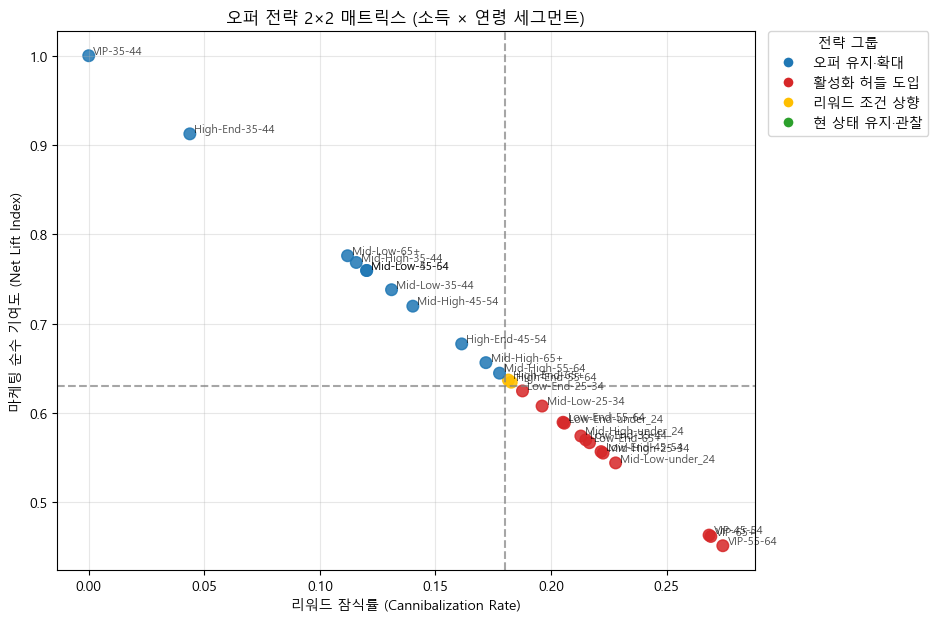

In [9]:
from matplotlib.lines import Line2D
# 2×2 전략 매트릭스 시각화(소득 x 연령 세그먼트)
import matplotlib.pyplot as plt 
plt.rcParams['font.family'] = 'Malgun Gothic'


color_map = {
    '오퍼 유지·확대': '#1f77b4',        #파랑
    '활성화 허들 도입': '#d62728',      #빨강
    '리워드 조건 상향': '#ffbf00',      #노랑
    '현 상태 유지·관찰': '#2ca02c'      #초록
}
plt.figure(figsize=(9, 7))

#산점도 (전략 그룹별 색상)
plt.scatter(
    income_age_target_pct['cannibalization_rate'],
    income_age_target_pct['net_lift_index'],
    c=income_age_target_pct['strategy_group'].map(color_map),
    s=70,
    alpha=0.85
)

#기준선 (중앙값 기준)
plt.axhline(0.63, linestyle='--', color='gray', alpha=0.7)
plt.axvline(0.18, linestyle='--', color='gray', alpha=0.7)

#소득 × 나이 라벨 붙이기
for (income, age), row in income_age_target_pct.iterrows():
    plt.text(
        row['cannibalization_rate'] + 0.002,
        row['net_lift_index'] + 0.002,
        f"{income}-{age}",
        fontsize=8,
        alpha=0.7
    )

#범례 생성
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label='오퍼 유지·확대',
           markerfacecolor='#1f77b4', markersize=8),

    Line2D([0], [0], marker='o', color='w',
           label='활성화 허들 도입',
           markerfacecolor='#d62728', markersize=8),

    Line2D([0], [0], marker='o', color='w',
           label='리워드 조건 상향',
           markerfacecolor='#ffbf00', markersize=8),

    Line2D([0], [0], marker='o', color='w',
           label='현 상태 유지·관찰',
           markerfacecolor='#2ca02c', markersize=8),
]

plt.legend(
    handles=legend_elements,
    title='전략 그룹',
    bbox_to_anchor=(1.02, 1),  
    loc='upper left',
    borderaxespad=0.
)

#축 / 제목
plt.xlabel('리워드 잠식률 (Cannibalization Rate)')
plt.ylabel('마케팅 순수 기여도 (Net Lift Index)')
plt.title('오퍼 전략 2×2 매트릭스 (소득 × 연령 세그먼트)')

plt.grid(alpha=0.3)
plt.show()

In [10]:
# A타입(오퍼 반응 구매) vs C타입(우연완료) 비교

# 전체 완료 오퍼 수 (A + C)
total_completed_cnt = offer_metrics['completed'].sum()
# C타입 완료 오퍼 수
c_completed_cnt = offer_metrics['completed_wo_view'].sum()
# A타입 완료 오퍼 수
a_completed_cnt = total_completed_cnt - c_completed_cnt

# 완료 기준 비율 (%)
a_completed_pct = round(a_completed_cnt / total_completed_cnt * 100, 2)
c_completed_pct = round(c_completed_cnt / total_completed_cnt * 100, 2)

#2. A타입 vs C타입 리워드 비교
# 전체 완료 오퍼 리워드 비용
total_reward_cost = (offer_metrics.loc[offer_metrics['completed'] == 1,'reward'].sum())
#C타입 완료 오퍼 리워드 비용
c_reward_cost = (offer_metrics.loc[offer_metrics['completed_wo_view'] == 1,'reward'].sum())
# A타입 완료 오퍼 리워드 비용
a_reward_cost = total_reward_cost - c_reward_cost
# 비용 기준 비율 (%)
a_reward_cost_pct = round(a_reward_cost / total_reward_cost * 100, 2)
c_reward_cost_pct = round(c_reward_cost / total_reward_cost * 100, 2)

# 평균 리워드 비용 비교 
avg_reward_a = ( offer_metrics.loc[offer_metrics['viewed_then_completed'] == True,'reward'].mean()).round(2)
avg_reward_c = (offer_metrics.loc[offer_metrics['completed_wo_view'] == 1,'reward'].mean()).round(2)
# ---------------------------------------------------------
# 기초통계 요약 테이블
summary = pd.DataFrame({
    '구분': ['A타입 (확인 후 완료)', 'C타입 (미확인 완료)'],
    '완료 건수': [a_completed_cnt, c_completed_cnt],
    '완료 비중(%)': [a_completed_pct, c_completed_pct],
    '리워드 비용': [a_reward_cost, c_reward_cost],
    '리워드 비용 비중(%)': [a_reward_cost_pct, c_reward_cost_pct],
    '평균 리워드 비용': [avg_reward_a,avg_reward_c]
})

summary

,구분,완료 건수,완료 비중(%),리워드 비용,리워드 비용 비중(%),평균 리워드 비용
0,A타입 (확인 후 완료),52774,82.46,132244.0,83.49,4.92
1,C타입 (미확인 완료),11226,17.54,26157.0,16.51,4.66


## 4. 결론

세그먼트를 더 세분화하는 것이 답이 아니었다.  
문제는 "누가 반응하는가"가 아니라 **"누가 오퍼 없이 구매하는가"**였다.

**분석 결과:**
- 전체 리워드의 **16.5%** — 마케팅 기여 없이 소진
- 마케팅 효율 **0.34** (Net Lift 기준) — $1 투자 시 $0.34 순 증대 매출 발생
- 고소득 세그먼트 — 잠식 매출이 순 증대 매출의 3배

**의사결정:**

| 문제 구조 | 실행 방향 |
|-----------|----------|
| C유형 자동 리워드 지급 | Opt-in 전환 파일럿 → 최대 $260,000 절감 (전체 규모 확장 기준) |
| 루틴형 고객 오퍼 낭비 | 상위 30% 오퍼 50% 축소 → 비용 절감 > 매출 손실 |
| 고소득 ROI 음수 구조 | 해당 세그먼트 오퍼 타입 변경 (D그룹 Opt-in) |

→ 절감 예산을 A/B 그룹에 집중 재배분 → 마케팅 ROI 구조적 개선 가능

---

*1개월 시뮬레이션 데이터 기준 — 전체 유저 확장 시 동일 비율 적용*